## Ablation study

Reviewing results in ablation study:

1- R2: normal and anomaly state (just 2 states)
We just claim 2 states: normal, anomal (identify by the time series anomaly detection IQR on weekly issue_closed)
2- R3: process categories 
5 category based on the regex on CONVENTIONAL_TYPES (link)
3- the combination of states and categories

Baseline: 
whole event log without any partitioning

Setups:
3 miners
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]
5 repository (to be unbiased about the quality of commit messages)
3 of them claimed that considering the conventional commit
https://github.com/commitizen-tools/commitizen
https://github.com/yargs/yargs
https://github.com/semantic-release/semantic-release


2 of the are famous finance repository, they are popular in terms of stars and forks
https://github.com/tauricresearch/tradingagents
https://github.com/HKUDS/Vibe-Trading


Descriptive metrics: like cycle time,..
Quality metrics: Precision, fitness and f score (token replay)
Model complexity metrics: size, cfc, simplicity


reporting f-score for whole log
reporitng weighted average :
normal/anomaly, commit categories, anomaly categories — sum(f_score * n_cases) / sum(n_cases) on that sheet, excluding whole



In [1]:
from pathlib import Path
import pandas as pd

DATASETS = [
    "commitizen",
    "TradingAgents",
    "Vibe-Trading",
    "yargs",
    "semantic-release",
]
MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]
PARTITIONS = [
    ("whole", "commit_categories", True),
    ("normal/anomaly states", "anomaly_normal", False),
    ("commit categories", "commit_categories", False),
    ("states + categories", "anomaly_categories", False),
]
TABLES = Path("results/tables")


def weighted_f(df, miner, whole_only):
    sub = df[df["discovery_method"] == miner]
    if whole_only:
        return sub.loc[sub["log_name"] == "whole", "f_score"].iloc[0]
    sub = sub[sub["log_name"] != "whole"]
    return (sub["f_score"] * sub["n_cases"]).sum() / sub["n_cases"].sum()


rows = []
for miner in MINERS:
    for label, sheet, whole_only in PARTITIONS:
        row = {"discovery_method": miner, "partition": label}
        for dataset in DATASETS:
            df = pd.read_excel(
                TABLES / dataset / "consolidated_results_tables.xlsx",
                sheet_name=sheet,
            )
            row[dataset] = weighted_f(df, miner, whole_only)
        rows.append(row)

comparison = pd.DataFrame(rows).set_index(["discovery_method", "partition"])

out_path = TABLES / "compare" / "f_score_ablation_comparison.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
comparison.to_csv(out_path)
print(f"Saved {out_path}")
comparison


Saved results\tables\compare\f_score_ablation_comparison.csv


commitizen  TradingAgents  \
discovery_method            partition                                          
inductive_IMf_noise_0.2     whole                    0.612254       0.679391   
                            normal/anomaly states    0.532808       0.708584   
                            commit categories        0.524767       0.618372   
                            states + categories      0.484548       0.661372   
split_miner_eps_0.2_eta_0.5 whole                    0.531106       0.387004   
                            normal/anomaly states    0.532836       0.418569   
                            commit categories        0.550592       0.387566   
                            states + categories      0.593382       0.458153   
heuristics_dep_0.5          whole                    0.517981       0.379064   
                            normal/anomaly states    0.519558       0.493185   
                            commit categories        0.542605       0.466700   
                            states + categories      0.553092       0.489230   

                                                   Vibe-Trading     yargs  \
discovery_method            partition                                       
inductive_IMf_noise_0.2     whole                      0.306520  0.466746   
                            normal/anomaly states      0.392996  0.513422   
                            commit categories          0.627709  0.475898   
                            states + categories        0.494225  0.502697   
split_miner_eps_0.2_eta_0.5 whole                      0.575421  0.637713   
                            normal/anomaly states      0.656604  0.555065   
                            commit categories          0.656049  0.651091   
                            states + categories        0.656622  0.693177   
heuristics_dep_0.5          whole                      0.388835  0.442786   
                            normal/anomaly states      0.555543  0.455536   
                            commit categories          0.556779  0.536600   
                            states + categories        0.625139  0.504920   

                                                   semantic-release  
discovery_method            partition                                
inductive_IMf_noise_0.2     whole                          0.276562  
                            normal/anomaly states          0.262491  
                            commit categories              0.333440  
                            states + categories            0.284136  
split_miner_eps_0.2_eta_0.5 whole                          0.401086  
                            normal/anomaly states          0.474362  
                            commit categories              0.518463  
                            states + categories            0.610735  
heuristics_dep_0.5          whole                          0.513899  
                            normal/anomaly states          0.544794  
                            commit categories              0.599962  
                            states + categories            0.599260

Saved results\figures\commitizen\cycle-time comparison.{png,pdf}


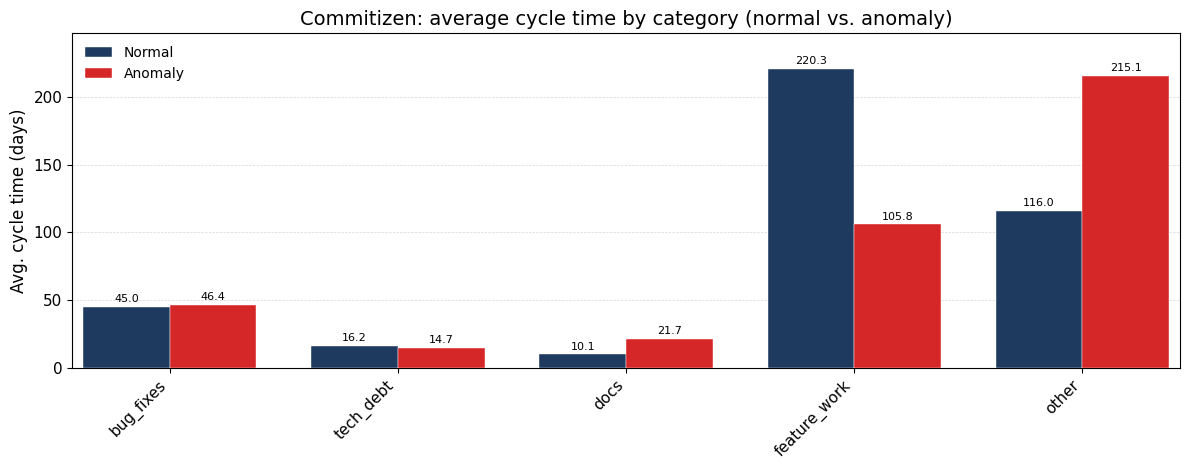

state,normal,anomaly
category,,
bug_fixes,45.045693,46.448382
tech_debt,16.204664,14.690126
docs,10.129875,21.724242
feature_work,220.316365,105.845988
other,116.014108,215.148435


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.commits import CATEGORIES
from functions.config import save_figure
from functions.plotting_anomaly import FIGURE_FONT

df = pd.read_excel(
    Path("results/tables/commitizen/consolidated_results_tables.xlsx"),
    sheet_name="anomaly_categories",
)
df = df[df["log_name"] != "whole"].drop_duplicates("log_name")
df["state"] = df["log_name"].str.split("_", n=1).str[0]
df["category"] = df["log_name"].str.split("_", n=1).str[1]

# Explicit left-to-right category order.
category_order = ["bug_fixes", "tech_debt", "docs", "feature_work", "other"]

wide = (
    df.pivot(index="category", columns="state", values="avg_cycle_time_days")
    [["normal", "anomaly"]]
    .reindex(category_order)
)

state_colors = {"normal": "#1F3A5F", "anomaly": "#D62728"}
state_labels = {"normal": "Normal", "anomaly": "Anomaly"}

with plt.rc_context(FIGURE_FONT):
    fig, ax = plt.subplots(figsize=(12, 4.8))
    x = np.arange(len(wide.index))
    width = 0.38

    for i, state in enumerate(["normal", "anomaly"]):
        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset,
            wide[state].values,
            width,
            color=state_colors[state],
            label=state_labels[state],
            edgecolor="white",
            linewidth=0.3,
            zorder=3,
        )
        ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right")
    ax.set_ylabel("Avg. cycle time (days)")
    #ax.set_xlabel("Commit category")
    ax.set_title("Commitizen: average cycle time by category (normal vs. anomaly)")

    # Horizontal grid only, behind the bars.
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Give the value labels a little headroom.
    ax.set_ylim(0, wide.max().max() * 1.12)
    ax.margins(x=0.01)

    ax.legend(loc="upper left", frameon=False)
    fig.tight_layout()

    figures_dir = Path("results/figures/commitizen")
    no_titles_dir = Path("results/figures_no_titles/commitizen")
    save_figure(fig, figures_dir, "cycle-time comparison", no_titles_dir=no_titles_dir)
    print(f"Saved {figures_dir / 'cycle-time comparison'}.{{png,pdf}}")
    plt.show()

wide